>**Projeto Processamento de Big Data** 


>**Grupo 4**: Camila Sousa 111017 | Carolina Brunheta 110888 | Miguel Correia 110786


>**2023/24**

>**Visualizações e conclusões**

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession \
    .builder \
    .appName("LondonBikeShareUsage") \
    .config("spark.driver.memory", "10g")\
    .config("spark.executor.memory", "10g")\
    .config("spark.driver.maxResultSize", "2048m") \
    .config("spark.sql.shuffle.partitions", 6) \
    .config("spark.sql.repl.eagereval.enabled", True) \
    .getOrCreate()

In [2]:
from IPython.core.display import HTML 
display(HTML("<style>pre { white-space: pre !important; }</style>"))

## Índice:

1. Explicação do problema
2. Limpeza dos dados
3. Análise exploratória
4. Treino e afinação do modelo
5. Aplicação do modelo
6. Conclusões

## 1. Explicação do problema

Atualmente, programas de compartilhamento de bicicletas que se baseiam em tecnologias digitais e de comunicação estão a tornar-se cada vez mais comuns.

Esses sistemas rastreiam individualmente cada bicicleta em circulação, gerando dados detalhados sobre cada aluguer realizado: informações como qual bicicleta foi retirada, de onde, para onde, por quanto tempo, em que data e hora, e por quem. Esses dados são armazenados em bancos de dados, formando um registo completo de todos os alugueres.

Em 2010, a cidade de Londres lançou seu próprio programa de compartilhamento de bicicletas, que rapidamente se tornou um dos maiores da Europa. 

No entanto, uma das preocupações dos utilizadores ao usufruir desses sistemas é o tempo necessário para as suas viagens. Entender a duração esperada de uma viagem de bicicleta pode influenciar as decisões dos utilizadores sobre qual sistema de transporte utilizar, que plano de rotas e horários traçar, e até mesmo que atividades escolher durante o trajeto.

Desta forma, fez-se um estudo do dataset london.csv (https://www.kaggle.com/datasets/ajohrn/bikeshare-usage-in-london-and-taipei-network), relativo a informações acerca de alugueres de bicicletas em Londres, entre 2017 e 2020, com o objetivo de prever a duração dos mesmos, utilizando as funcionalidades disponibilizadas pela plataforma Apache Spark.




## 2. Limpeza dos dados

O dataset em estudo contém 9 variáveis, nomeadamente: 
* 'rental_id' - identificador do aluguer
* 'duration' - duração, em segundos, do aluguer
* 'bike_id' - identificador da bicicleta
* 'end_rental_date_time' - data e hora do fim do aluguer
* 'end_station_id' - identificador da estação de chegada
* 'end_station_name' - nome da estação de chegada
* 'start_rental_date_ time' - data e hora do início do aluguer
* 'start_station_id' - identificador da estação de partida
* 'start_station_name' - nome da estação de partida


Antes da importação do ficheiro, foi iniciada a sessão spark e definido o schema, ou seja, o tipo de cada variável. O ficheiro foi importado e verificou-se se o schema foi corretamente implementado.

De seguida, observaram-se algumas linhas do dataset, para perceber  melhor o contexto dos dados.

Inicialmente, a estrutura da base de dados era: 

In [3]:
filename = "./london_counts.csv"
estrutura = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
estrutura.show()

+----------------+-----------------+
|numero_de_linhas|numero_de_colunas|
+----------------+-----------------+
|        38215560|                9|
+----------------+-----------------+



Fez-se um análise de valores omissos, com a qual se verificou o seguinte:

In [4]:
filename = "./london_nulls.csv"
omissos= spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
omissos.show()

+--------------------+-----------+
|             feature|count_nulls|
+--------------------+-----------+
|end_rental_date_time|      67617|
|start_rental_date...|          0|
|    end_station_name|      68213|
|      end_station_id|      68213|
|  start_station_name|          0|
|    start_station_id|          0|
|            duration|      67617|
|           rental_id|          0|
|             bike_id|         17|
+--------------------+-----------+



Uma vez que o número de valores omissos é baixo em comparação com o número total de linahs do dataset, procedeu-se à eliminação das linhas com valores em falta. 
No final, o número de linhas do dataset ficou igual a:

In [5]:
filename = "./total_count.txt"
total_count = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
total_count.show()

+--------+
|38147278|
+--------+
+--------+



Assim, foram eliminadas 68282 instâncias. 

Analisaram-se os valores únicos e outliers. 
Observaram-se alguns valores extremos na variável 'duration', bem como valores negativos. As linhas com duração negativa foram eliminadas, bem como as linhas com duração igual a zero. A partir da elaboração de um boxplot, verificou-se a distribuição desta variável, e tomou-se a decisão de limitar os valores da duração a 5000 segundos, para não "fugir" muito aos intervalos interquartis. 

Considerou-se necessária a criação de novas variáveis, a fim de enriquecer a informação proporcionada pelo dataset. 
Desta forma, utlizaram-se as variáveis do tipo timestamp, nomeadamente 'start_rental_date_time' e 'end_rental_date_time', para criar as variáveis:
* 'dayofweek' - dia da semana em que se fez o aluguer
* 'start_period_of_day' e 'end_period_of_day' - período do dia em que se começou/acabou o aluguer
*  'season' - estação do ano na data do aluguer

O link da nossa base de dados continha, também, um csv com dados acerca da localização das estações de Londres, com as variáveis: 
* 'station_id' - identificador da estação
* 'station_name' - nome da estação
* 'longitude' - coordenada de longitude da estação
* 'latitude' - coordenada de latitude da estação


Decidiu-se integrar este ficheiro na nossa base de dados, a fim de dar mais significado às variáveis referentes às estações de início e fim de aluguer. O dataset foi importado e tinha a seguinte estrutura: 

In [6]:
filename = "./london_stations_count.csv"
stations_count = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
stations_count.show()

+----------------+-----------------+
|numero_de_linhas|numero_de_colunas|
+----------------+-----------------+
|             802|                4|
+----------------+-----------------+



Verificou-se que, nesta base de dados, não existiam duplicados nem valores omissos, e fez-se a observação de valores únicos.

Adicionaram-se, no dataset principal, colunas correspondentes às coordenadas longitude e latitude de 'start_station_id' e 'end_station_id' que se encontravam registadas no ficheiro london_stations. Apagaram-se as linhas que ficaram com valores omissos nesta variável. Assim, a base de dados london passou a conter a localização geográfica de cada estação. 

Por fim, foi criada a variável 'distance_between_stations' que, com base nas coordenadas das estações, indica a distância, em km, entre a estação de partida e de chegada de um aluguer de bicicleta. 


O último passo da limpeza dos dados foi a eliminação de colunas desnecessárias. Foram, então, eliminadas as variáveis 'rental_id', 'bike_id', 'end_station_name' e 'start_station_name', pois não são relevantes para o objetivo do trabalho. 

No final, o dataset limpo tinha a seguinte estrutura: 

In [7]:
filename = "./london_count_final.csv"
count_final = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
count_final.show()

+----------------+-----------------+
|numero_de_linhas|numero_de_colunas|
+----------------+-----------------+
|        37145238|               18|
+----------------+-----------------+



Guardou-se a base de dados limpa num parquet, bem como um sub-conjunto com 30% das linhas totais.

## 3. Análise Exploratória

Na etapa de análise exploratória dos dados, tentaram-se encontrar padrões e relações entre variáveis, a fim de compreender melhor os dados. 

Fizeram-se vários gráficos exploratórios, para procurar conclusões acerca do funcionamento dos alugueres de bibicletas em Londres e os fatores que os influenciam. 

Criaram-se gráficos que exploram a sazonalidade nos alugueres durante o ano, as diferenças na frequência de alugueres em diferentes horas do dia, em diversos dias da semana e em diferentes estações do ano, e as distâncias das viagens. 

As conclusões retiradas em cada gráfico estão expressas no notebook de Análise exploratória dos dados.

Compilando esses insights, retira-se que:

* O padrão sazonal de alugueres de bicicletas mostra picos recorrentes anualmente, com um aumento significativo durante o fim da primavera (maio) e o verão (junho, julho e agosto), atingindo o auge em julho. Em contrapartida, os meses de inverno (dezembro, janeiro e fevereiro) apresentam o menor número de alugueres, indicando que o clima mais quente é mais atrativo para o uso de bicicletas.

* Durante todo o ano, os dias úteis registam o maior número de alugueres. Nos meses mais frios (outubro a março), a percentagem de alugueres nos fins de semana é menor comparada aos meses mais quentes, possivelmente devido às condições climáticas adversas. No verão, há um aumento nos alugueres durante os fins de semana, refletindo um aumento na recreação e no turismo.

* As horas diurnas registam significativamente mais alugueres que as noturnas, com picos às 8h e 17h, correspondendo às "horas de ponta" de deslocamento para o trabalho. Sábados e domingos têm um padrão distinto, com alugueres distribuídos do meio-dia ao final da tarde, correspondendo a viagens de lazer durante o dia. 

* As viagens de bicicleta são mais frequentes para distâncias curtas. Viagens acima de 2 km são menos comuns, indicando que para distâncias maiores, os utilizadores preferem outros meios de transporte (autocarro, metro, por exemplo). O aluguer de bicicletas parece servir mais como uma solução para "preencher as lacunas" entre as estações de transporte público e os locais de trabalho.

De seguida, exploraram-se relações de algumas variáveis com a variável alvo, ou seja, a duração. 

Obtiveram-se alguns gráficos interessantes:

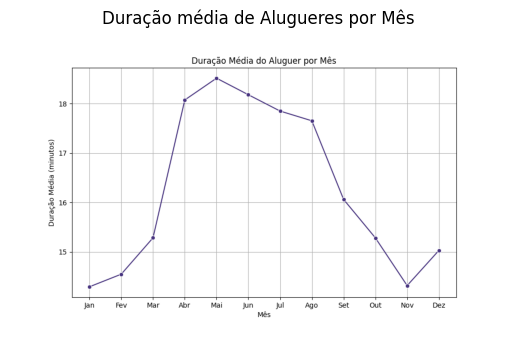

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Caminho do arquivo da imagem
filename = "./duracao_media_alugueres_por_mes.png"

# Carregar a imagem
image = Image.open(filename)

# Mostrar a imagem
plt.imshow(image)
plt.axis('off')  # Desativar os eixos
plt.title("Duração média de Alugueres por Mês")
plt.show()

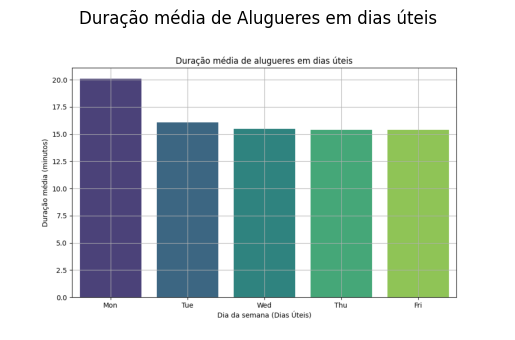

In [9]:
# Caminho do arquivo da imagem
filename = "./duracao_media_alugueres_dias_uteis.png"

# Carregar a imagem
image = Image.open(filename)

# Mostrar a imagem
plt.imshow(image)
plt.axis('off')  # Desativar os eixos
plt.title("Duração média de Alugueres em dias úteis")
plt.show()

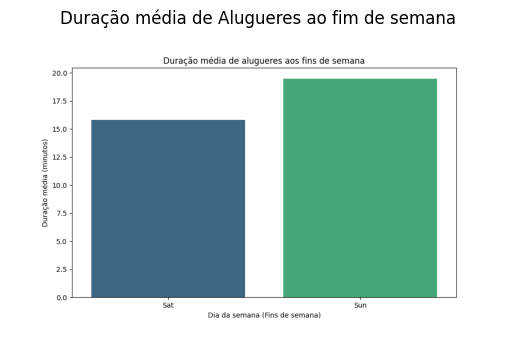

In [10]:
# Caminho do arquivo da imagem
filename = "./duracao_media_alugueres_fim_semana.png"

# Carregar a imagem
image = Image.open(filename)

# Mostrar a imagem
plt.imshow(image)
plt.axis('off')  # Desativar os eixos
plt.title("Duração média de Alugueres ao fim de semana")
plt.show()

Retiraram-se insights interessantes acerca da variável alvo:

* Há uma clara influência do clima nos padrões de aluguer. O primeiro gráfico, mostrando a duração média dos alugueres por mês, evidencia um padrão sazonal claro. Durante os meses mais quentes, especialmente de maio a agosto, a duração média dos alugueres é significativamente maior, atingindo o pico em maio e junho, com viagens de, aproximadamente, 18-19 minutos. Nos meses de inverno (dezembro a fevereiro), a duração média cai para cerca de 15 minutos. Isso indica que climas mais quentes incentivam alugueres mais longos, possivelmente devido a condições climáticas favoráveis para passeios e atividades ao ar livre.

* Observa-se que a segunda-feira tem a maior duração média, cerca de 20 minutos, enquanto os outros dias da semana (terça a sexta-feira) mantêm uma duração média mais constante, entre 15 e 16 minutos. Este padrão pode dever-se à motivação e disposição para iniciar a semana de forma produtiva, levando a decisões de realizar trajetos mais longos de bicicleta. Nos restantes dias, os alugueres são mais curtos e funcionais.

* A duração média aos sábados é de, aproximadamente, 15 minutos, enquanto aos domingos aumenta para cerca de 20 minutos. Este aumento nos domingos pode ser atribuído ao tempo livre adicional e ao uso mais recreativo das bicicletas, permitindo passeios mais longos.















Para concluir a análise exploratória, testou-se a criação e visualização de um grafo para representar as estaçõea (nós) e as viagens de aluguer de bicicletas que as conectam (arestas), a fim de explorar formas diferentes de representar a base de dados. 

Neste seguimento, considerou-se relevante estudar as centralidades de proximidade (distância média mais curta de um nó para todos os outros nós na rede) e centralidade de vetor próprio (importância de um nó com base não apenas nas suas próprias conexões, mas também na importância dos nós aos quais está conectado). 

Chegou-se à conclusão que a centralidade de proximidade é mais relevante para a estação inicial (reflete a importância da estação em termos de acessibilidade e conectividade), enquanto que a centralidade de vetor próprio é mais relevante para a estação final (uma estação final com alta centralidade de vetor próprio é um destino popular, onde muitas estações convergem). 

Assim, acrescentaram-se ao dataset as variáveis:
* 'closeness_centrality_start' - centralidade de proximidade da estação inicial
* 'eigenvector_centrality_end' - centralidade de vetor próprio da estação final

Foram, também, procuradas e detetadas comunidades de estações, ou seja, grupos de estações que estão fortemente interconectadas entre si, o que pode revelar rotas comuns e com mais demanda. 

Fez-se uma matriz de correlação de variáveis numéricas, e eliminaram-se variáveis que não se consideravam relevantes por já terem sido criadas outras variáveis que exploram a informação nelas contida. Estas variáveis foram 'end_rental_date_time' e 'start_rental_date_time'. 

Novamente, guardou-se o dataset, com as novas modificações, num parquet.

## 4. Treino e afinação do modelo

Para esta fase do trabalho, começou-se por fazer a divisão do dataset em conjuntos de treino, validação e teste. 

Optou-se por uma divisão 70/15/15, ou seja, 70% de dados para treino, 15% para validação e 15% para teste.

No conjunto de treino, ficaram  7767952 linhas,  1665389  no conjunto de validação e 1665796 no conjunto de teste.

De seguida, procedeu-se à criação de variáveis dummy, para as variáveis categóricas que se vão usar para previsão. Para tal, codificaram-se as colunas categóricas em índices numéricos, que possam ser usados como input do modelo. Esses índices foram transformados em vetores binários, que são mais adequados para o modelo. Por fim, juntaram-se as colunas num único vetor, que será o input do modelo. 



Para a previsão, foi utilizado o algoritmo RandomForest de regressão. Este algoritmo consiste na criação de uma "floresta" de árvores de decisão, que se baseiam, cada uma delas, em amostras aleatórias dos dados, onde a decisão final é tomada com base nas saídas combinadas de todas as árvores. Este algorimo oferece uma alternativa às árvores de decisão, ao evitar o overfitting. Para uma tarefa de regressão, como é o caso, a previsão final é obtida pela média das previsões de todas as árvores. É um modelo robusto a ruídos nos dados e a variações nas amostras de treino.


Foi criado um pipeline, que foi aplicado ao conjunto de treino. Para avaliar a previsão, usaram-se as métricas RMSE, R-squared e MAPE, pelas seguintes razões: 

* RMSE - mede o erro médio, mas penaliza erros maiores de forma mais significativa, o que é útil porque os erros maiores (por exemplo, previsões muito subestimadas ou sobrestimadas) podem ter um impacto desproporcionalmente grande na experiência do utilizador. Portanto, minimizar o RMSE pode levar a previsões mais precisas e consistentes em relação à duração real das viagens.

* MAPE -  erro médio como uma percentagem do valor real da duração da viagem, o que é útil porque fornece uma medida relativa do erro, o que pode ser mais interpretável. Por exemplo, um MAPE de 10% indica que, em média, as previsões estão dentro de 10% do valor real da duração da viagem.

* R-squared - um valor alto indica que o modelo explica a maior parte da variabilidade na duração de viagem. Isto sugere que o modelo capta bem as tendências e padrões subjacentes nos dados, o que proporciona uma maior confiança nas previsões feitas pelo modelo. 

As métricas obtidas no modelo inicial foram:

In [11]:
filename = "./metrics1.csv"
metricas_iniciais = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
metricas_iniciais.show()

+------+------------------+
|Metric|             Value|
+------+------------------+
|  MAPE|0.6146910876670256|
|  RMSE|  613.903735466818|
|    R2| 0.308908685064913|
+------+------------------+



O MAPE indica que, em média, as previsões do modelo estão desviadas cerca de 69.54% do valor real. Este valor é bastante alto, sugerindo que o modelo não está a prever com grande precisão. 
O RMSE de 622.29 minutos sugere que as previsões do modelo têm um erro médio elevado.
O valor de 0.2910 de R-squared significa que o modelo explica apenas cerca de 29.10% da variabilidade nas durações dos alugueres. 


Para tentar melhorar estas métricas, fez-se um ajuste nos parâmetros do modelo, mas não houve melhoria.

Fez-se um novo ajuste, cujas métricas foram:

In [12]:
filename = "./metrics3.csv"
metricas_ajustadas = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
metricas_ajustadas.show()

+------+-------------------+
|Metric|              Value|
+------+-------------------+
|  MAPE| 0.5255280355987231|
|  RMSE|  589.9946671306155|
|    R2|0.36169087130107247|
+------+-------------------+



Houve alguma melhoria nas métricas.

Considerou-se interessante experimentar o GBTRegressor, que utiliza um processo de boosting sequencial, onde cada árvore é ajustada aos erros residuais do modelo anterior. 

Contudo, os resultados não mostraram melhorias significativas em comparação com o melhor modelo até então. 



Desta forma, decidiu-se considerar o segundo modelo de RandomForest ajustado como o melhor modelo. 

Guardaram-se a pipeline e o modelo treinado em disco, e avançou-se para a próxima fase.

## 5. Aplicação do modelo

Importaram-se a pipeline e o modelo, e o modelo foi aplicado ao conjunto de teste. As métricas obtidas foram: 

In [13]:
filename = "./metrics.csv"
metricas = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(filename)
metricas.show()

+------+-------------------+
|Metric|              Value|
+------+-------------------+
|  MAPE| 0.5247547604280578|
|    R2|0.36199503929444954|
|  RMSE|   589.952117434969|
+------+-------------------+



## Conclusões

No processo de modelação, exploraram-se diferentes configurações de modelos de regressão. Inicialmente, construiu-se um modelo RandomForestRegressor padrão. Decidiu-se testar diferentes combinações de hiperparâmetros, como o número de árvores (numTrees) e a profundidade máxima da árvore (maxDepth), para otimizar o desempenho do modelo. Após experimentar várias combinações, identificou-se que o modelo RandomForestRegressor com numTrees=50 e maxDepth=10 obteve o melhor desempenho.

Embora se tenha explorado também o GBTRegressor, esperando que a sua natureza sequencial de boosting pudesse capturar relações mais complexas nos dados, não se observaram melhorias significativas em relação ao RandomForestRegressor. 

Os resultados finais mostram que o modelo RandomForestRegressor com numTrees=50 e maxDepth=10 alcançou um RMSE de 589.95, um R2 de 0.362 e um MAPE de 0.525. Embora esses resultados representem uma melhoria em relação ao modelo inicial, reconhece-se que há espaço para aprimoramentos adicionais, especialmente considerando a natureza complexa dos dados.

Primeiramente, a aplicação de técnicas de validação cruzada teria permitido uma avaliação mais robusta do desempenho dos modelos, ajudando a reduzir o risco de overfitting e fornecendo estimativas mais confiáveis das suas capacidades preditivas. Da mesma forma, a utilização de técnicas como GridSearch para a escolha otimizada de hiperparâmetros poderia ter permitido uma exploração mais sistemática do espaço de hiperparâmetros e identificado configurações mais eficazes para os modelos.

Além disso, é importante reconhecer que a abordagem concentrou-se em modelos de regressão supervisionada. Explorar outros algoritmos mais adequados para o problema e os dados, como redes neuronais, poderia revelar insights adicionais sobre a estrutura subjacente aos dados e, potencialmente, melhorar a precisão das previsões.

Outra consideração importante é a possibilidade de realizar uma análise não supervisionada para identificar padrões e estruturas nos dados que podem não ter sido capturados pela abordagem supervisionada. Tal poderia  fornecer uma compreensão mais profunda dos dados.

Em suma, embora o modelo obtido não seja o mais promissor para os dados e objetivo em estudo, reconhece-se que o processo de modelação é iterativo e contínuo.